In [60]:
!pip install datasets
!pip install textblob


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [61]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from textblob import TextBlob

In [62]:
# Load dataset from HuggingFace
ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = ds['train'].to_pandas()

df = df[df['language'] == 'en'].reset_index(drop=True)

print(f"Total English tickets: 28261")
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Total English tickets: 28261
Dataset Shape: (28261, 16)

Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

First few rows:


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,None,None,None,None


In [63]:
# Basic info
print("Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe(include='all')

Data Types:
subject      object
body         object
answer       object
type         object
queue        object
priority     object
language     object
version     float64
tag_1        object
tag_2        object
tag_3        object
tag_4        object
tag_5        object
tag_6        object
tag_7        object
tag_8        object
dtype: object

Basic Statistics:


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,24622,28260,28255,28261,28261,28261,28261,16338.000000,28261,28245,28148,25677,16301,7908,3699,1608
unique,19064,23665,23619,4,10,3,1,NaN,128,280,475,621,736,710,583,405
top,Investment Analytics Tools,"Hello Customer Support, I am inquiring about o...","Hello, regarding the billing error issue for a...",Incident,Technical Support,medium,en,NaN,Security,Performance,IT,Tech Support,Tech Support,Tech Support,Tech Support,Documentation
freq,2,2,2,11213,8149,11570,28261,NaN,5366,5006,5505,5926,4059,1548,306,98
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.359958,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167.184913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing Values Summary:
         Missing Count  Missing %
tag_8            26653  94.310180
tag_7            24562  86.911291
tag_6            20353  72.017975
tag_5            11960  42.319805
version          11923  42.188882
subject           3639  12.876402
tag_4             2584   9.143342
tag_3              113   0.399844
tag_2               16   0.056615
answer               6   0.021231
body                 1   0.003538


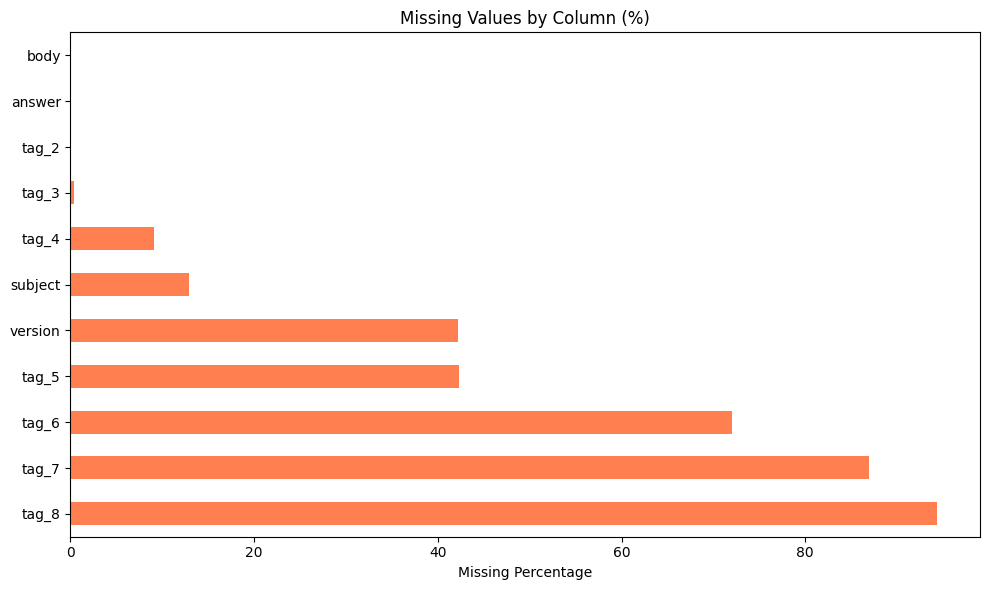

In [64]:
# Missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize
plt.figure(figsize=(10, 6))
missing_df[missing_df['Missing Count'] > 0]['Missing %'].plot(kind='barh', color='coral')
plt.title('Missing Values by Column (%)')
plt.xlabel('Missing Percentage')
plt.tight_layout()
plt.show()


=== TOP 20 TAGS ===
Tech Support: 14444
IT: 14052
Performance: 11423
Feedback: 8724
Documentation: 7657
Bug: 7534
Security: 6602
Feature: 5792
Disruption: 4249
Outage: 3594
Technical: 3531
Network: 3251
Product: 2764
Sales: 2610
Resolution: 2414
Guidance: 1997
Recovery: 1773
Billing: 1738
Crash: 1726
Integration: 1399


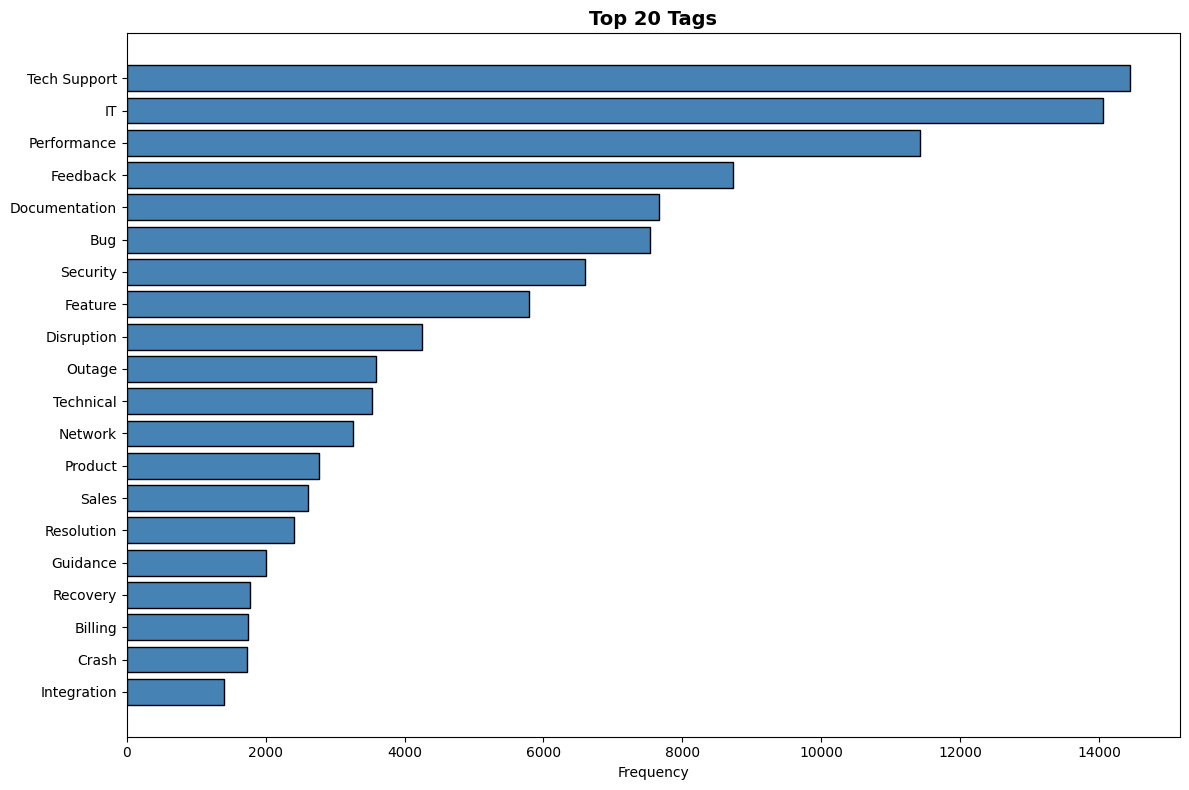

In [65]:
# Collect all tags
tags = []
tag_cols = [f'tag_{i}' for i in range(1, 9)]

for col in tag_cols:
    tags.extend(df[col].dropna().tolist())

tag_counts = Counter(tags)
top_tags = tag_counts.most_common(20)

print("\n=== TOP 20 TAGS ===")
for tag, count in top_tags:
    print(f"{tag}: {count}")

# Visualize
plt.figure(figsize=(12, 8))
tags_plot, counts_plot = zip(*top_tags)
plt.barh(range(len(tags_plot)), counts_plot, color='steelblue', edgecolor='black')
plt.yticks(range(len(tags_plot)), tags_plot)
plt.xlabel('Frequency')
plt.title('Top 20 Tags', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [66]:
# Tag coverage analysis
print("\n=== TAG COVERAGE ===")
for col in tag_cols:
    none_count = (df[col] == 'None').sum() + df[col].isnull().sum()
    filled_count = len(df) - none_count
    print(f"{col}: {filled_count} filled ({filled_count/len(df)*100:.1f}%), {none_count} missing/None ({none_count/len(df)*100:.1f}%)")


=== TAG COVERAGE ===
tag_1: 28261 filled (100.0%), 0 missing/None (0.0%)
tag_2: 28245 filled (99.9%), 16 missing/None (0.1%)
tag_3: 28148 filled (99.6%), 113 missing/None (0.4%)
tag_4: 25677 filled (90.9%), 2584 missing/None (9.1%)
tag_5: 16301 filled (57.7%), 11960 missing/None (42.3%)
tag_6: 7908 filled (28.0%), 20353 missing/None (72.0%)
tag_7: 3699 filled (13.1%), 24562 missing/None (86.9%)
tag_8: 1608 filled (5.7%), 26653 missing/None (94.3%)



=== TEXT LENGTH STATISTICS ===

Character count:
count    28261.000000
mean       371.265843
std        202.882721
min          4.000000
25%        203.000000
50%        365.000000
75%        533.000000
max       1793.000000
Name: text_length, dtype: float64

Word count:
count    28261.000000
mean        55.352677
std         31.249665
min          1.000000
25%         30.000000
50%         54.000000
75%         79.000000
max        272.000000
Name: word_count, dtype: float64


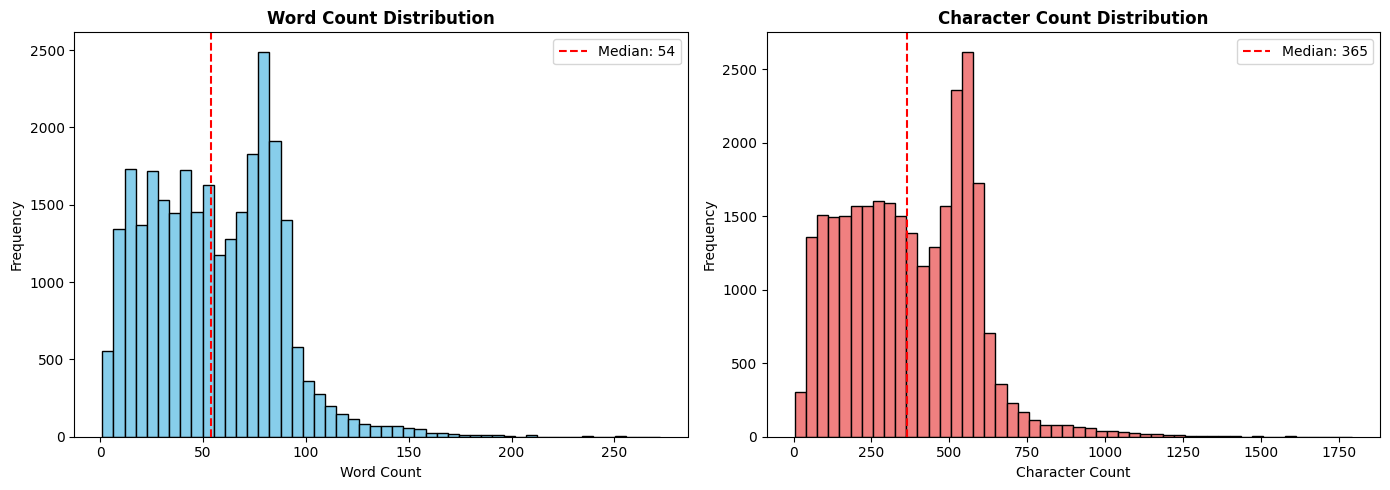

In [67]:
# Add text length features
df['text_length'] = df['body'].astype(str).apply(len)
df['word_count'] = df['body'].astype(str).apply(lambda x: len(x.split()))

print("\n=== TEXT LENGTH STATISTICS ===")
print("\nCharacter count:")
print(df['text_length'].describe())
print("\nWord count:")
print(df['word_count'].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[0].legend()

axes[1].hist(df['text_length'], bins=50, edgecolor='black', color='lightcoral')
axes[1].set_title('Character Count Distribution', fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['text_length'].median(), color='red', linestyle='--', label=f'Median: {df["text_length"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()


=== TYPE vs PRIORITY ===
priority  high   low  medium
type                        
Change    1160   607    1223
Incident  4834  2080    4299
Problem   2172  1245    2478
Request   2751  1842    3570


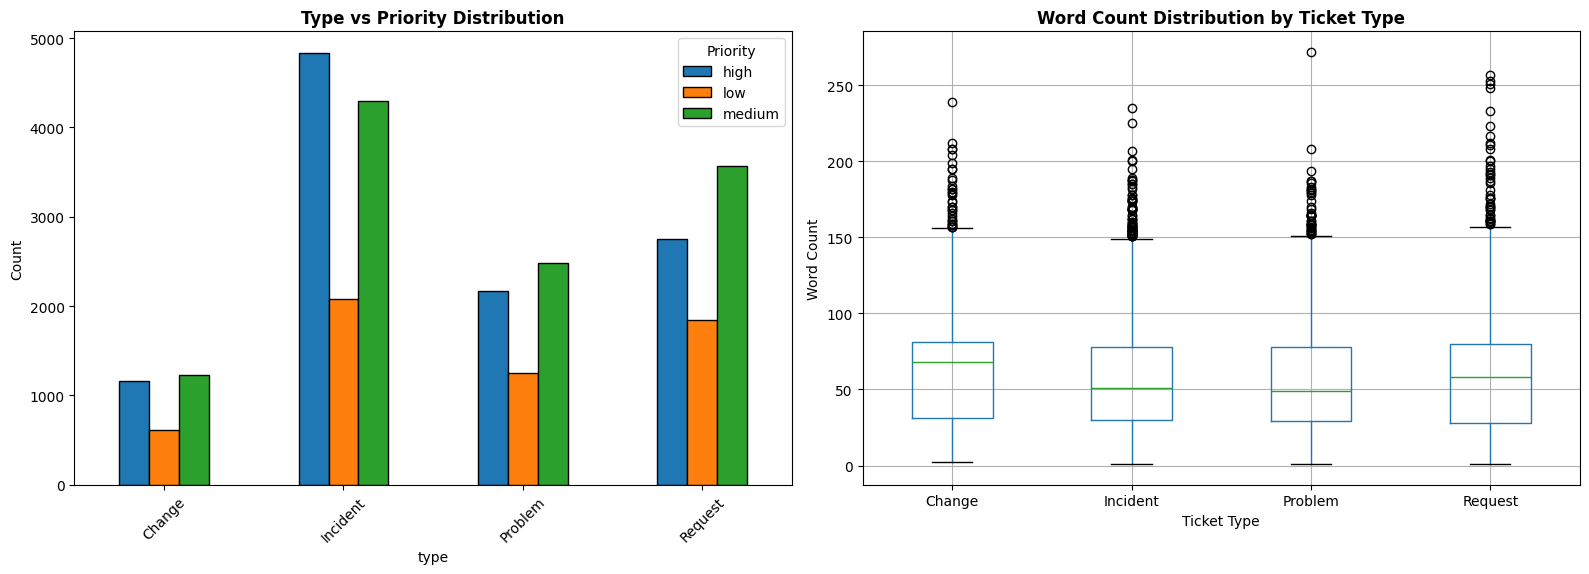

In [68]:
# Type vs Priority
print("\n=== TYPE vs PRIORITY ===")
type_priority = pd.crosstab(df['type'], df['priority'])
print(type_priority)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
type_priority.plot(kind='bar', ax=axes[0], edgecolor='black', stacked=False)
axes[0].set_title('Type vs Priority Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Priority')

# Word count by type (boxplot)
df.boxplot(column='word_count', by='type', ax=axes[1])
axes[1].set_title('Word Count Distribution by Ticket Type', fontweight='bold')
axes[1].set_xlabel('Ticket Type')
axes[1].set_ylabel('Word Count')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

In [69]:
print("\n=== LANGUAGE vs TYPE ===")
lang_type = pd.crosstab(df['language'], df['type'])
print(lang_type)

# Visualize if multiple languages
if len(df['language'].unique()) > 1:
    plt.figure(figsize=(10, 6))
    lang_type.plot(kind='bar', edgecolor='black')
    plt.title('Language vs Type Distribution', fontweight='bold')
    plt.ylabel('Count')
    plt.legend(title='Type')
    plt.tight_layout()
    plt.show()


=== LANGUAGE vs TYPE ===
type      Change  Incident  Problem  Request
language                                    
en          2990     11213     5895     8163


In [70]:
# Text cleaning NLP oriented
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

CUSTOM_STOPWORDS = set(ENGLISH_STOP_WORDS) | {
    'please', 'help', 'thanks', 'hello', 'hi', 'dear', 'team', 
    'support', 'customer', 'regards', 'thank', 'hope'
}

def clean_text(text):
    """Clean text for NLP analysis"""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

df['clean_text'] = df['body'].apply(clean_text)

print("\n TEXT CLEANING COMPLETE ")
print("\nOriginal:")
print(df['body'].iloc[0][:200])
print("\nCleaned:")
print(df['clean_text'].iloc[0][:200])


 TEXT CLEANING COMPLETE 

Original:
Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to acc

Cleaned:
dear customer support teamnni am writing to report a significant problem with the centralized account management portal which currently appears to be offline this outage is blocking access to account 



=== TOP 20 WORDS ===
data: 18239
issue: 13305
assistance: 9574
information: 9282
provide: 9099
software: 8941
appreciate: 8821
security: 7257
problem: 6955
greatly: 6305
analytics: 6284
medical: 6135
investment: 6031
integration: 5804
tools: 5575
digital: 5238
resolve: 5223
matter: 5088
project: 4921
issues: 4884


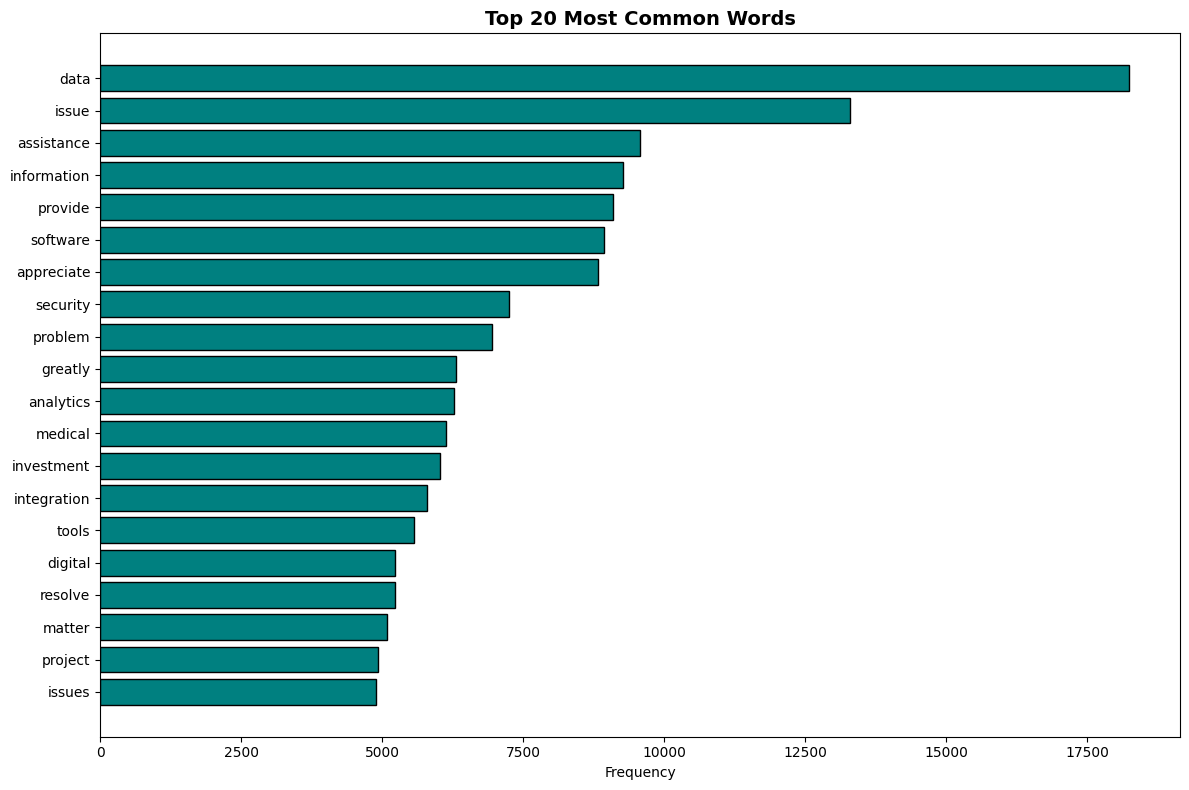

In [71]:
# Word frequency analysis
all_words = " ".join(df['clean_text']).split()
filtered_words = [w for w in all_words if w not in CUSTOM_STOPWORDS and len(w) > 2]

word_freq = Counter(filtered_words)
top_words = word_freq.most_common(20)

print("\n=== TOP 20 WORDS ===")
for word, count in top_words:
    print(f"{word}: {count}")

# Visualize
plt.figure(figsize=(12, 8))
words, counts = zip(*top_words)
plt.barh(range(len(words)), counts, color='teal', edgecolor='black')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [72]:
# Word analysis by type
print("\nTOP WORDS BY TICKET TYPE ")

for ticket_type in df['type'].dropna().unique():
    subset = df[df['type'] == ticket_type]['clean_text']
    words = " ".join(subset).split()
    words = [w for w in words if w not in CUSTOM_STOPWORDS and len(w) > 2]
    
    print(f"\n{ticket_type.upper()}:")
    top_10 = Counter(words).most_common(10)
    for word, count in top_10:
        print(f"  {word}: {count}")


TOP WORDS BY TICKET TYPE 

INCIDENT:
  issue: 8721
  data: 6380
  software: 5204
  problem: 4585
  assistance: 3852
  resolve: 3413
  recent: 3392
  issues: 2915
  matter: 2794
  updates: 2776

REQUEST:
  data: 5748
  information: 5557
  provide: 5160
  appreciate: 3649
  assistance: 2935
  forward: 2763
  details: 2690
  tools: 2665
  greatly: 2472
  medical: 2456

PROBLEM:
  issue: 4447
  data: 3768
  software: 2410
  problem: 2364
  assistance: 2108
  resolve: 1716
  issues: 1623
  despite: 1470
  appreciate: 1460
  matter: 1449

CHANGE:
  data: 2343
  request: 1446
  tools: 1295
  security: 1215
  enhance: 1179
  integration: 1079
  improve: 1077
  appreciate: 995
  information: 980
  update: 949


In [73]:
#tfidf
print("\nTF-IDF VECTORIZATION ")

tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    min_df=5,
    max_df=0.8
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Sparsity: {(1.0 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.2%}")


TF-IDF VECTORIZATION 
TF-IDF Matrix Shape: (28261, 500)
Sparsity: 95.46%


In [74]:
# K-Means clustering with different k values
print("\nK-MEANS CLUSTERING ")

k_range = range(3, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_matrix)
    
    inertia = kmeans.inertia_
    sil_score = silhouette_score(tfidf_matrix, labels, sample_size=5000)
    
    inertias.append(inertia)
    silhouette_scores.append(sil_score)
    
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.3f}")

# Find optimal k (elbow + silhouette)
optimal_k_sil = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal k (by silhouette): {optimal_k_sil}")


K-MEANS CLUSTERING 
k=3: Inertia=25093.05, Silhouette=0.034
k=4: Inertia=24642.89, Silhouette=0.038
k=5: Inertia=24335.59, Silhouette=0.038
k=6: Inertia=24079.15, Silhouette=0.036
k=7: Inertia=23884.01, Silhouette=0.033
k=8: Inertia=23694.77, Silhouette=0.033
k=9: Inertia=23541.01, Silhouette=0.036
k=10: Inertia=23386.35, Silhouette=0.035

Optimal k (by silhouette): 5


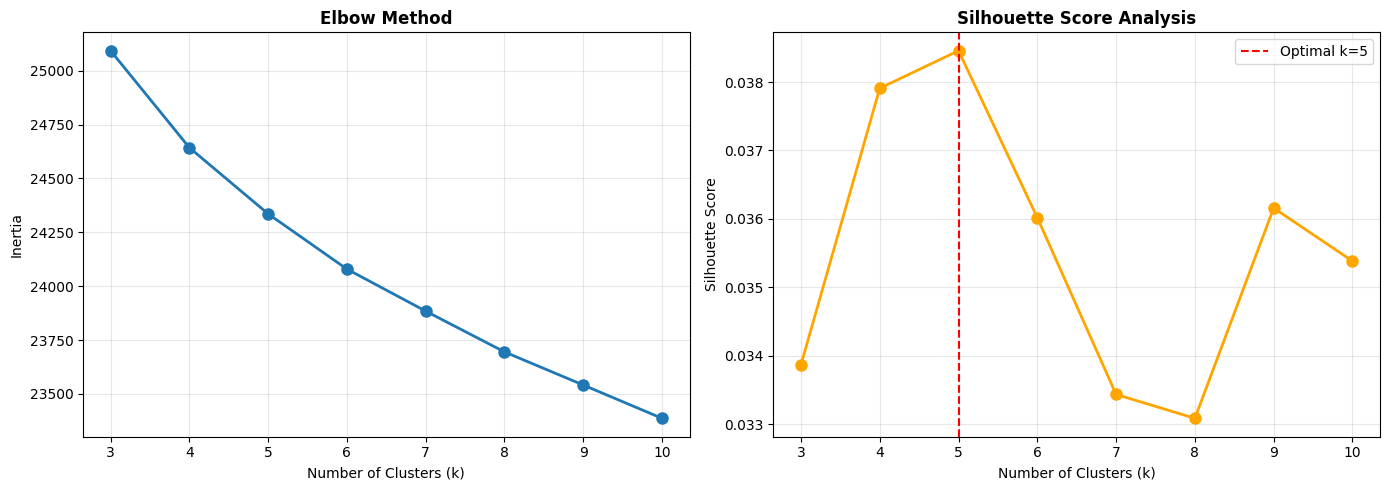

In [75]:
# Visualize elbow and silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='orange')
axes[1].axvline(optimal_k_sil, color='red', linestyle='--', label=f'Optimal k={optimal_k_sil}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score Analysis', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


=== FINAL CLUSTERING (k=5) ===

Cluster sizes:
cluster
0     3188
1     5537
2    11872
3     3784
4     3880
Name: count, dtype: int64


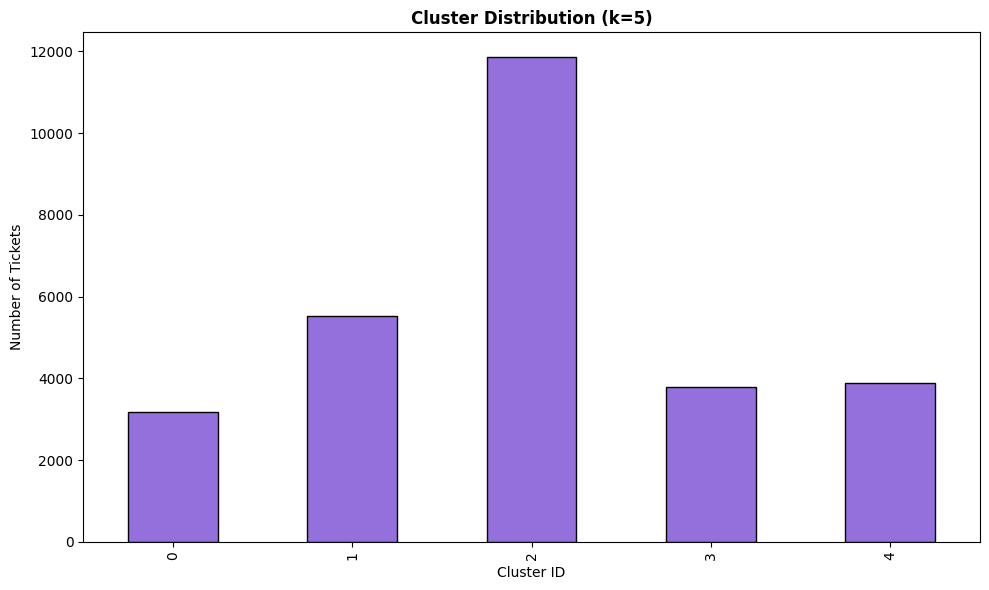

In [76]:
# Fit final K-Means model with optimal k
optimal_k = 5  # Can adjust based on elbow/silhouette plots

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(tfidf_matrix)

print(f"\n=== FINAL CLUSTERING (k={optimal_k}) ===")
print("\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

# Visualize cluster distribution
plt.figure(figsize=(10, 6))
df['cluster'].value_counts().sort_index().plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title(f'Cluster Distribution (k={optimal_k})', fontweight='bold')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

In [77]:
# Analyze clusters - top terms and samples
print("\n=== CLUSTER ANALYSIS ===")

feature_names = tfidf_vectorizer.get_feature_names_out()

for i in range(optimal_k):
    print(f"\n{'='*60}")
    print(f"CLUSTER {i}")
    print(f"{'='*60}")
    
    # Cluster size
    cluster_docs = df[df['cluster'] == i]
    print(f"Size: {len(cluster_docs)} tickets ({len(cluster_docs)/len(df)*100:.1f}%)")
    
    # Top terms
    cluster_center = kmeans_final.cluster_centers_[i]
    top_terms_idx = cluster_center.argsort()[-10:][::-1]
    top_terms = [feature_names[idx] for idx in top_terms_idx]
    print(f"\nTop terms: {', '.join(top_terms)}")
    
    # Type distribution in cluster
    print(f"\nType distribution:")
    print(cluster_docs['type'].value_counts())
    
    # Sample tickets
    print(f"\nSample tickets:")
    samples = cluster_docs['body'].sample(min(2, len(cluster_docs)), random_state=42)
    for idx, sample in enumerate(samples, 1):
        print(f"  [{idx}] {sample[:150]}...")


=== CLUSTER ANALYSIS ===

CLUSTER 0
Size: 3188 tickets (11.3%)

Top terms: investment, analytics, data, tools, optimization, decisions, optimizing, optimize, provide, investments

Type distribution:
type
Request     1739
Change       657
Incident     456
Problem      336
Name: count, dtype: int64

Sample tickets:
  [1] Enhancing Investment Strategies Through Data Analytics...
  [2] Dear Customer Support, I am reaching out to request enhancements to our data analytics tools to improve investment optimization and decision-making pr...

CLUSTER 1
Size: 5537 tickets (19.6%)

Top terms: security, medical, data, access, breach, systems, information, measures, patient, sensitive

Type distribution:
type
Incident    2063
Request     1802
Problem     1020
Change       652
Name: count, dtype: int64

Sample tickets:
  [1] I would like to obtain guidance on the optimal security strategies for safeguarding medical data on Ubuntu operating systems. Given the critical natur...
  [2] Could you provid


 HIERARCHICAL CLUSTERING 


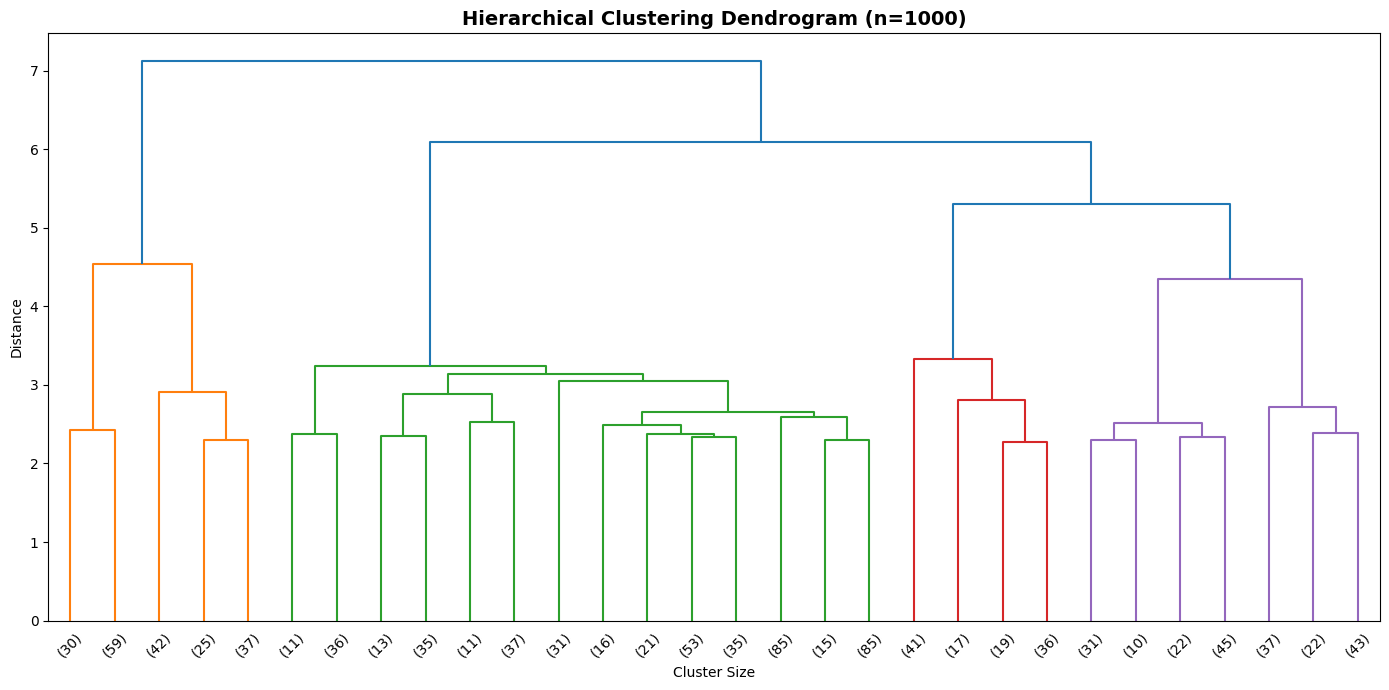


Dendrogram shows hierarchical relationships between clusters.
Cut height can be adjusted to get different numbers of clusters.


In [78]:
# Hierarchical Agglomerative Clustering (HAC)
from scipy.cluster.hierarchy import dendrogram, linkage

print("\n HIERARCHICAL CLUSTERING ")

# Sample for computational efficiency
sample_size = min(1000, len(df))
sample_indices = df.sample(sample_size, random_state=42).index
tfidf_sample = tfidf_matrix[sample_indices]

# Compute linkage
linkage_matrix = linkage(tfidf_sample.toarray(), method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_font_size=10)
plt.title(f'Hierarchical Clustering Dendrogram (n={sample_size})', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

print("\nDendrogram shows hierarchical relationships between clusters.")
print("Cut height can be adjusted to get different numbers of clusters.")

In [79]:
# PCA for dimensionality reduction
from sklearn.decomposition import PCA

print("\nDIMENSIONALITY REDUCTION (PCA) ")

# Use sample for visualization (full dataset can be slow)
viz_sample_size = min(5000, len(df))
sample_indices = df.sample(viz_sample_size, random_state=42).index

pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(tfidf_matrix[sample_indices].toarray())

print(f"\nExplained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")


DIMENSIONALITY REDUCTION (PCA) 

Explained variance: 6.27%
PC1: 3.28%
PC2: 2.99%


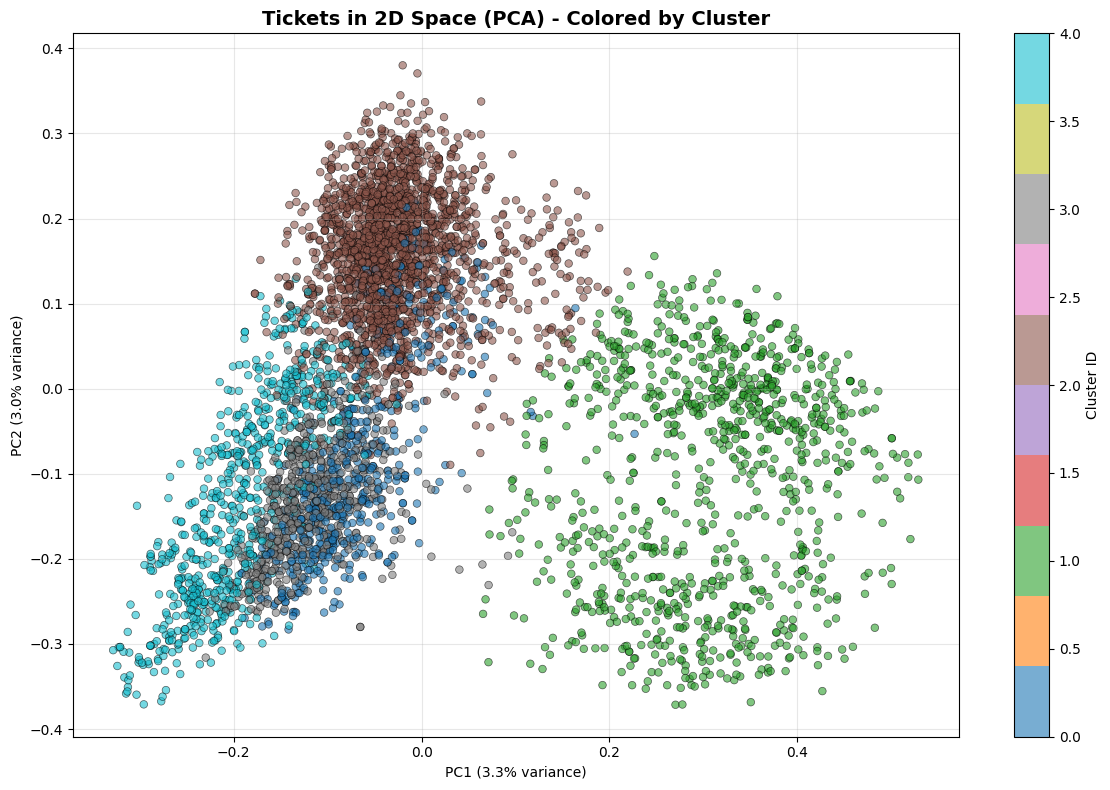

In [80]:
# Visualize in 2D space - colored by cluster
plt.figure(figsize=(12, 8))

clusters = df.loc[sample_indices, 'cluster']
scatter = plt.scatter(coords_2d[:, 0], coords_2d[:, 1], 
                     c=clusters, cmap='tab10', 
                     alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

plt.colorbar(scatter, label='Cluster ID')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Tickets in 2D Space (PCA) - Colored by Cluster', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

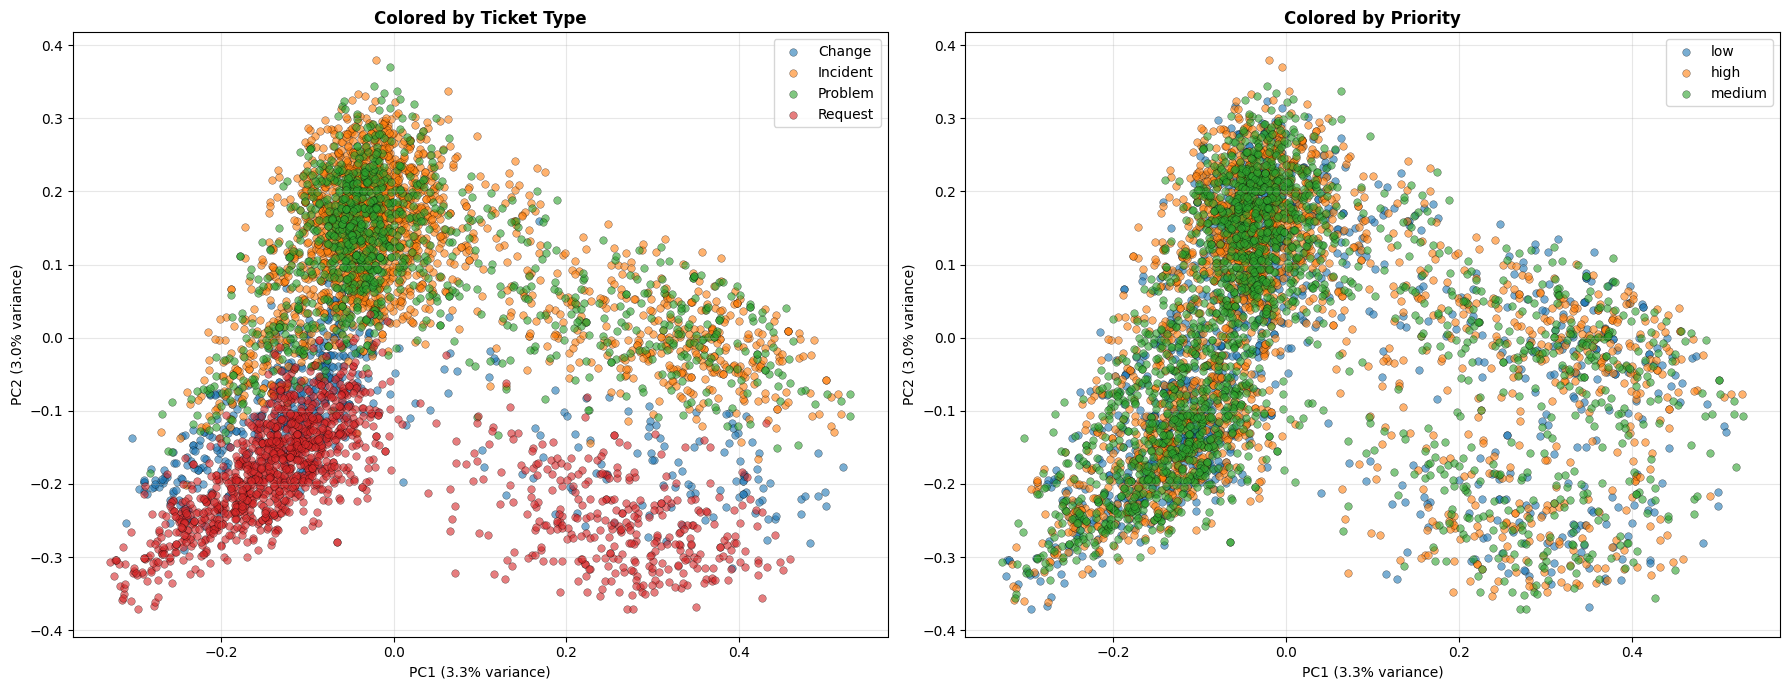

In [81]:
# Visualize in 2D space - colored by type
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Color by type
types = df.loc[sample_indices, 'type']
for ticket_type in types.unique():
    mask = types == ticket_type
    axes[0].scatter(coords_2d[mask, 0], coords_2d[mask, 1], 
                   label=ticket_type, alpha=0.6, s=30, edgecolors='black', linewidth=0.3)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('Colored by Ticket Type', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Color by priority
priorities = df.loc[sample_indices, 'priority']
for priority in priorities.unique():
    mask = priorities == priority
    axes[1].scatter(coords_2d[mask, 0], coords_2d[mask, 1], 
                   label=priority, alpha=0.6, s=30, edgecolors='black', linewidth=0.3)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('Colored by Priority', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
# Sentiment scoring


print("\n=== SENTIMENT ANALYSIS ===")
print("Computing sentiment scores...")

df['sentiment_polarity'] = df['body'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['sentiment_subjectivity'] = df['body'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

# Categorize sentiment
df['sentiment_category'] = pd.cut(
    df['sentiment_polarity'],
    bins=[-1, -0.1, 0.1, 1],
    labels=['Negative', 'Neutral', 'Positive']
)

print("\nSentiment Polarity Statistics:")
print(df['sentiment_polarity'].describe())

print("\nSentiment Category Distribution:")
print(df['sentiment_category'].value_counts())
print(df['sentiment_category'].value_counts(normalize=True) * 100)


=== SENTIMENT ANALYSIS ===
Computing sentiment scores...

Sentiment Polarity Statistics:
count    28261.000000
mean         0.109890
std          0.177696
min         -0.600000
25%          0.000000
50%          0.078571
75%          0.216667
max          1.000000
Name: sentiment_polarity, dtype: float64

Sentiment Category Distribution:
sentiment_category
Neutral     13230
Positive    12815
Negative     2216
Name: count, dtype: int64
sentiment_category
Neutral     46.813630
Positive    45.345175
Negative     7.841195
Name: proportion, dtype: float64


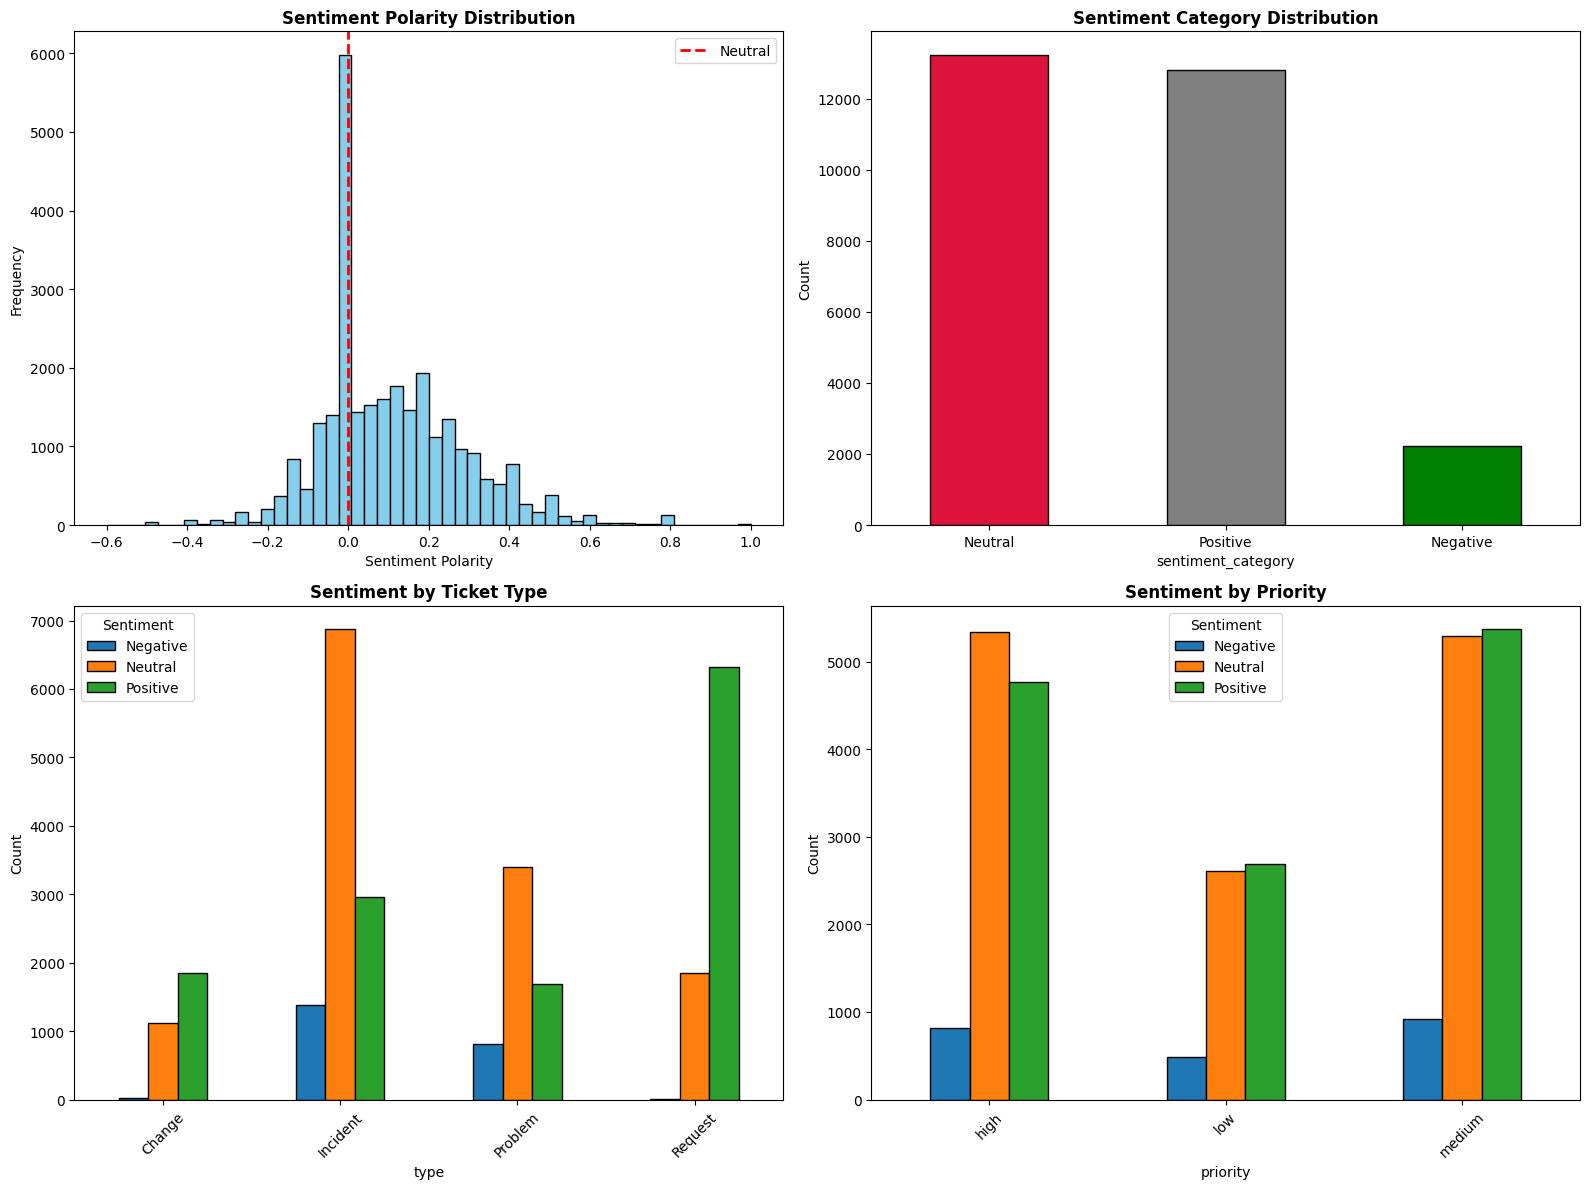

In [83]:
# Visualize sentiment distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sentiment polarity distribution
axes[0, 0].hist(df['sentiment_polarity'], bins=50, edgecolor='black', color='skyblue')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[0, 0].set_xlabel('Sentiment Polarity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sentiment Polarity Distribution', fontweight='bold')
axes[0, 0].legend()

# Sentiment category counts
df['sentiment_category'].value_counts().plot(kind='bar', ax=axes[0, 1], 
                                              color=['crimson', 'gray', 'green'], 
                                              edgecolor='black')
axes[0, 1].set_title('Sentiment Category Distribution', fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Sentiment by type
sentiment_type = pd.crosstab(df['type'], df['sentiment_category'])
sentiment_type.plot(kind='bar', ax=axes[1, 0], stacked=False, edgecolor='black')
axes[1, 0].set_title('Sentiment by Ticket Type', fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Sentiment')

# Sentiment by priority
sentiment_priority = pd.crosstab(df['priority'], df['sentiment_category'])
sentiment_priority.plot(kind='bar', ax=axes[1, 1], stacked=False, edgecolor='black')
axes[1, 1].set_title('Sentiment by Priority', fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Sentiment')

plt.tight_layout()
plt.show()


 SENTIMENT BY CLUSTER 

Cluster 0:
sentiment_category
Positive    61.856964
Neutral     31.304893
Negative     6.838143
Name: proportion, dtype: float64

Cluster 1:
sentiment_category
Neutral     52.754199
Positive    34.856420
Negative    12.389381
Name: proportion, dtype: float64

Cluster 2:
sentiment_category
Neutral     57.496631
Positive    32.951482
Negative     9.551887
Name: proportion, dtype: float64

Cluster 3:
sentiment_category
Positive    78.065539
Neutral     21.564482
Negative     0.369979
Name: proportion, dtype: float64

Cluster 4:
sentiment_category
Positive    52.757732
Neutral     43.015464
Negative     4.226804
Name: proportion, dtype: float64


<Figure size 1200x600 with 0 Axes>

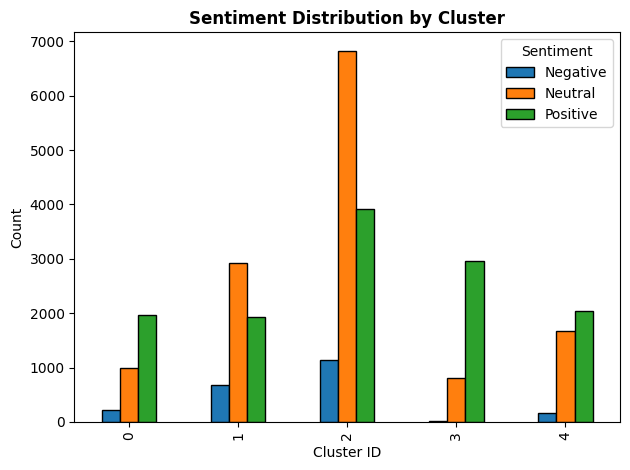

In [85]:
# Sentiment by cluster
print("\n SENTIMENT BY CLUSTER ")

for i in range(optimal_k):
    cluster_sentiment = df[df['cluster'] == i]['sentiment_category'].value_counts(normalize=True) * 100
    print(f"\nCluster {i}:")
    print(cluster_sentiment)

# Visualize
plt.figure(figsize=(12, 6))
sentiment_cluster = pd.crosstab(df['cluster'], df['sentiment_category'])
sentiment_cluster.plot(kind='bar', edgecolor='black')
plt.title('Sentiment Distribution by Cluster', fontweight='bold')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()